In [1]:
import ot 


In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone as fo

## list all dataset
print(fo.list_datasets())

# Close any zombie sessions that might be hanging
fo.close_app()

['FLPLAN', 'dugong', 'flplan200', 'flplanpatches']


In [2]:
dataset = fo.load_dataset("FLPLAN")

In [12]:
import json 
from pathlib import Path

json_ids = json.load(open(Path("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/splits_seeds012.json")))
json_ids['0']

{'p5': {'aclr': ['6a155c1000810aef404b0236', '6a155c1000810aef404b024c'],
  'random': ['6a155c1000810aef404b026e', '6a155c1000810aef404b0240']},
 'p10': {'aclr': ['6a155c1000810aef404b024e',
   '6a155c1000810aef404b0235',
   '6a155c1000810aef404b0257',
   '6a155c1000810aef404b0220',
   '6a155c1000810aef404b024c'],
  'random': ['6a155c1000810aef404b026e',
   '6a155c1000810aef404b0240',
   '6a155c1000810aef404b0261',
   '6a155c1000810aef404b0270',
   '6a155c1000810aef404b0242']},
 'p20': {'aclr': ['6a155c1000810aef404b0262',
   '6a155c1000810aef404b0235',
   '6a155c1000810aef404b0254',
   '6a155c1000810aef404b022d',
   '6a155c1000810aef404b0269',
   '6a155c1000810aef404b0241',
   '6a155c1000810aef404b024a',
   '6a155c1000810aef404b026d',
   '6a155c1000810aef404b024c',
   '6a155c1000810aef404b0221',
   '6a155c1000810aef404b021f'],
  'random': ['6a155c1000810aef404b026e',
   '6a155c1000810aef404b0240',
   '6a155c1000810aef404b0261',
   '6a155c1000810aef404b0242',
   '6a155c1000810aef404b02

In [ ]:
dataset

In [3]:
dataset.list_saved_views()

['view_test0', 'view_test1', 'view_test2']

In [6]:
view_test0 = dataset.load_saved_view("view_test0")
view_test0.values("filepath")

['/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_26_03_10/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214.jpeg',
 '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_26_03_10/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_213.jpeg',
 '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_26_03_10/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_105.jpeg',
 '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10/images/FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_208.jpeg',
 '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10/images/FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_227.jpeg',
 '/share/home/e2406743/dataset/new_dataset/UM_DUGONG_2025/FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a3f_26_03_10/images/FPLAN_M4_UM_M46_F1_2025_P_4-699849b7e7a

In [7]:
import glob
def get_files_by_stem(filepath_stem, patch_folder):
    dict_out = {}
    foolder_meta = os.path.join(patch_folder, 'metadata')
    list_meta = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.json')))
    foolder_meta = os.path.join(patch_folder, 'images')
    list_images = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.jpg')))
    foolder_meta = os.path.join(patch_folder, 'labels')
    list_labels = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.txt')))
    dict_out['metadata'] = list_meta
    dict_out['label'] = list_labels
    dict_out['images'] = list_images
    return dict_out

def mapdict_patches_filepath(list_paths, patch_folder):
    """
    Map each filepath into three tiles-filepaths respectively to images, labels and metadata. 
    """
    dict_map_filepath = {}
    for path in list_paths:
        stem = Path(path).stem
        dict_map_filepath[stem] = get_files_by_stem(stem, patch_folder)

    ## flat dict
    filepath_all_images   = [f for d in dict_map_filepath.values() for f in d.get('images', [])]
    filepath_all_labels   = [f for d in dict_map_filepath.values() for f in d.get('label', [])]
    filepath_all_metadata = [f for d in dict_map_filepath.values() for f in d.get('metadata', [])]

    ## -------------
    print(f'images:{len(filepath_all_images)}')
    print(f"labels:{len(filepath_all_labels)}")
    print(f"metadata:{len(filepath_all_metadata)}")

    return filepath_all_images, filepath_all_labels, filepath_all_metadata

In [10]:
from pathlib import Path
mapdict_patches_filepath(view_test0.values("filepath"),
                         patch_folder= "/share/home/e2406743/dataset/exported_img/new_dataset_flplan200")

images:61
labels:61
metadata:61


(['/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_3316_4640_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_3080_4400_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_3080_4640_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_3316_4400_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_214__tile_2200_0_n.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_213__tile_440_4640_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M46_F1_2025_P_2-699847233596f_213__tile_3316_4640_n.jp

In [19]:
list_filepaths = dataset.select(json_ids['0']['p10']['random']).values("filepath")

In [3]:
from ot.backend import get_backend_list

In [17]:
patches_dir = "/share/home/e2406743/dataset/exported_img/new_dataset_flplan200"


In [21]:
## MAPDICT
import glob
def get_files_by_stem(filepath_stem, patch_folder):
    dict_out = {}
    foolder_meta = os.path.join(patch_folder, 'metadata')
    list_meta = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.json')))
    foolder_meta = os.path.join(patch_folder, 'images')
    list_images = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.jpg')))
    foolder_meta = os.path.join(patch_folder, 'labels')
    list_labels = list(glob.glob(os.path.join(foolder_meta, f'{filepath_stem}__*.txt')))
    dict_out['metadata'] = list_meta
    dict_out['label'] = list_labels
    dict_out['images'] = list_images
    return dict_out

def mapdict_patches_filepath(list_paths, patch_folder):
    """
    Map each filepath into three tiles-filepaths respectively to images, labels and metadata. 
    """
    dict_map_filepath = {}
    for path in list_paths:
        stem = Path(path).stem
        dict_map_filepath[stem] = get_files_by_stem(stem, patch_folder)

    ## flat dict
    filepath_all_images   = [f for d in dict_map_filepath.values() for f in d.get('images', [])]
    filepath_all_labels   = [f for d in dict_map_filepath.values() for f in d.get('label', [])]
    filepath_all_metadata = [f for d in dict_map_filepath.values() for f in d.get('metadata', [])]

    ## -------------
    print(f'images:{len(filepath_all_images)}')
    print(f"labels:{len(filepath_all_labels)}")
    print(f"metadata:{len(filepath_all_metadata)}")

    return filepath_all_images, filepath_all_labels, filepath_all_metadata

In [24]:
json_ids.items()

dict_items([('0', {'p5': {'aclr': ['6a155c1000810aef404b0236', '6a155c1000810aef404b024c'], 'random': ['6a155c1000810aef404b026e', '6a155c1000810aef404b0240']}, 'p10': {'aclr': ['6a155c1000810aef404b024e', '6a155c1000810aef404b0235', '6a155c1000810aef404b0257', '6a155c1000810aef404b0220', '6a155c1000810aef404b024c'], 'random': ['6a155c1000810aef404b026e', '6a155c1000810aef404b0240', '6a155c1000810aef404b0261', '6a155c1000810aef404b0270', '6a155c1000810aef404b0242']}, 'p20': {'aclr': ['6a155c1000810aef404b0262', '6a155c1000810aef404b0235', '6a155c1000810aef404b0254', '6a155c1000810aef404b022d', '6a155c1000810aef404b0269', '6a155c1000810aef404b0241', '6a155c1000810aef404b024a', '6a155c1000810aef404b026d', '6a155c1000810aef404b024c', '6a155c1000810aef404b0221', '6a155c1000810aef404b021f'], 'random': ['6a155c1000810aef404b026e', '6a155c1000810aef404b0240', '6a155c1000810aef404b0261', '6a155c1000810aef404b0242', '6a155c1000810aef404b0221', '6a155c1000810aef404b0236', '6a155c1000810aef404b02

In [23]:
mapdict_patches_filepath(list_filepaths,
                         patches_dir
                         )

images:18
labels:18
metadata:18


(['/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_204__tile_2200_4400_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_204__tile_1760_3960_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_204__tile_2200_3960_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_204__tile_1760_4400_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_204__tile_3316_2640_n.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_201__tile_440_4640_p.jpg',
  '/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_M4_UM_M40_F1_2025_P_3-69983e8785b05_201__tile_440_4400_p.

In [ ]:
ot.backend

'Backend'

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import ot
from pathlib import Path
from PIL import Image
from kornia.augmentation import AugmentationSequential, RandomHorizontalFlip, RandomVerticalFlip


In [ ]:
class OTColorTransfer(nn.Module):
    """
    Per-image OT color transfer using SinkhornTransport.
    Each image in the batch is matched to a randomly drawn reference
    from a preloaded pool, maximising water-color diversity.

    Args:
        reference_dir : folder of reference images (jpg/png)
        n_samples     : pixels sampled for OT fit (500–1000 is the sweet spot)
        reg_e         : Sinkhorn entropy regularisation (0.05–0.5)
        p             : probability of applying the transfer per image
        max_pool_size : cap on how many references to load into GPU memory
    """
    def __init__(
        self,
        reference_dir: str,
        n_samples: int = 500,
        reg_e: float = 0.1,
        p: float = 0.5,
        max_pool_size: int = 50,
    ):
        super().__init__()
        self.n_samples = n_samples
        self.reg_e = reg_e
        self.p = p

        # Load reference images into a single GPU tensor at init
        # Shape: (pool_size, H_ref, W_ref, 3) — we keep them as flat pixel lists
        pool = self._load_pool(reference_dir, max_pool_size)
        # pool is a list of (N_i, 3) float32 tensors (flattened pixels per image)
        # Store as a python list of buffers — sizes may differ
        for i, pixels in enumerate(pool):
            self.register_buffer(f"ref_{i}", pixels)
        self.pool_size = len(pool)

    def _load_pool(self, directory: str, max_size: int):
        paths = sorted(Path(directory).glob("*"))
        paths = [p for p in paths if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
        paths = paths[:max_size]
        pool = []
        for path in paths:
            img = Image.open(path).convert("RGB")
            arr = np.array(img).astype(np.float32) / 255.0   # (H, W, 3)
            pixels = torch.from_numpy(arr.reshape(-1, 3))     # (H*W, 3)
            pool.append(pixels)
        return pool

    def _get_ref_pixels(self, idx: int) -> torch.Tensor:
        return getattr(self, f"ref_{idx}")   # (N_ref_pixels, 3)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """
        images: (B, 3, H, W) float32 [0, 1]
        returns: (B, 3, H, W) float32 [0, 1] — color-transferred where applied
        """
        out = images.clone()
        B, C, H, W = images.shape

        for b in range(B):
            # Stochastic skip
            if torch.rand(1).item() > self.p:
                continue

            # Random reference from pool
            ref_idx = torch.randint(0, self.pool_size, (1,)).item()
            ref_pixels = self._get_ref_pixels(ref_idx)  # (N_ref, 3), on same device

            # Flatten source image to pixels
            src_pixels = images[b].permute(1, 2, 0).reshape(-1, C)  # (H*W, 3)

            # Sample for OT fit
            idx_s = torch.randint(0, src_pixels.shape[0], (self.n_samples,))
            idx_t = torch.randint(0, ref_pixels.shape[0], (self.n_samples,))
            Xs = src_pixels[idx_s].cpu().numpy().astype(np.float64)
            Xt = ref_pixels[idx_t].cpu().numpy().astype(np.float64)

            # Fit Sinkhorn transport on sampled pixels
            transport = ot.da.SinkhornTransport(reg_e=self.reg_e, verbose=False)
            transport.fit(Xs=Xs, Xt=Xt)

            # Apply mapping to all pixels
            all_src = src_pixels.cpu().numpy().astype(np.float64)
            transported = transport.transform(Xs=all_src)           # (H*W, 3)
            transported = np.clip(transported, 0.0, 1.0).astype(np.float32)

            result = torch.from_numpy(transported).to(images.device)
            out[b] = result.reshape(H, W, C).permute(2, 0, 1)

        return out

# model preparation

In [1]:
checkpoint = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/checkpoints/NNN_NC_SEED63_augm_0510_1843/hf_export"

In [ ]:
from transformers import AutoImageProcessor
checkpoint = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/checkpoints/NNN_NC_SEED63_augm_0510_1843/hf_export"
autoimage_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"width": 640, "height": 640},  # Match RT-DETR's expected input size
    use_fast=True,
)

In [ ]:
import albumentations as A

# Define augmentations for training
train_augmentation = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.HueSaturationValue(p=0.1),
        A.Perspective(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="coco",  # RT-DETR expects COCO format (x_min, y_min, width, height)
        label_fields=["class_labels"],
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

# Validation: Only clip boxes to image boundaries
val_augmentation = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"],
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

In [3]:
import albumentations as A

# Define augmentations for training
train_augmentation = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.HueSaturationValue(p=0.1),
        A.Perspective(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="coco",  # RT-DETR expects COCO format (x_min, y_min, width, height)
        label_fields=["class_labels"],
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

# Validation: Only clip boxes to image boundaries
val_augmentation = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"],
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

In [42]:
from __future__ import annotations
from pathlib import Path
from typing import List, Dict, Optional, Union, Tuple
import json
import os
import numpy as np
import torch
from PIL import Image
import albumentations as A
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from transformers import AutoImageProcessor

def collate_fn(batch: List[Tuple[torch.Tensor, Dict]]) -> Dict:
    """Collate function for DataLoader: stacks pixel_values and keeps labels as a list."""
    return {
        "pixel_values": torch.stack([item[0] for item in batch]),
        "labels": [item[1] for item in batch],
    }


class DugongDataset(Dataset):
    def __init__(
        self,
        list_image_filepath: List[Union[str, Path]],
        list_label_filepath: List[Union[str, Path]],
        processor: AutoImageProcessor,
        augmentor: Optional[A.Compose] = None,
    ):
        """
        PyTorch Dataset for RT-DETR dugong detection.
        Loads images and YOLO-format labels, applies augmentation, and preprocesses for RT-DETR.

        Args:
            list_image_filepath: List of image file paths.
            list_label_filepath: List of YOLO label file paths (1:1 with images).
            processor: AutoImageProcessor for normalization/resizing.
            augmentor: Albumentations Compose object for augmentation (None for val/test).
        """
        # Convert to Path objects and sort
        self.list_image_filepath = [Path(p) for p in sorted(list_image_filepath)]
        self.list_label_filepath = [Path(p) for p in sorted(list_label_filepath)]

        # Validate lengths
        assert len(self.list_image_filepath) == len(self.list_label_filepath), (
            f"Mismatch: {len(self.list_image_filepath)} images vs {len(self.list_label_filepath)} labels"
        )

        # Validate all images exist
        for img_path in self.list_image_filepath:
            assert img_path.exists(), f"Image not found: {img_path}"

        self.processor = processor
        self.augmentor = augmentor

    def __len__(self) -> int:
        return len(self.list_image_filepath)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict]:
        # --- Load Image ---
        image_path = self.list_image_filepath[idx]
        image = Image.open(image_path).convert("RGB")
        img_w, img_h = image.size

        # --- Load YOLO Annotations ---
        label_path = self.list_label_filepath[idx]
        annotations = []
        if label_path.exists():
            try:
                with open(label_path, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:  # Skip malformed lines
                            continue
                        cls_id, xc, yc, w, h = map(float, parts)
                        # Convert YOLO (normalized cx,cy,w,h) → COCO absolute (x_min, y_min, w, h)
                        x_min = (xc - w / 2) * img_w
                        y_min = (yc - h / 2) * img_h
                        abs_w = w * img_w
                        abs_h = h * img_h
                        annotations.append({
                            "bbox": [x_min, y_min, abs_w, abs_h],
                            "category": int(cls_id),  # 0 for dugong
                        })
            except Exception as e:
                print(f"⚠️ Failed to load {label_path}: {e}. Using empty annotations.")

        # --- Apply Augmentation (Albumentations) ---
        if self.augmentor and annotations:
            try:
                # Albumentations expects numpy array + COCO format
                image_np = np.array(image)
                bboxes = [ann["bbox"] for ann in annotations]
                class_labels = [ann["category"] for ann in annotations]

                transformed = self.augmentor(
                    image=image_np,
                    bboxes=bboxes,
                    class_labels=class_labels,
                )
                image = Image.fromarray(transformed["image"])
                bboxes = transformed["bboxes"]
                class_labels = transformed["class_labels"]
            except Exception as e:
                print(f"⚠️ Augmentation failed for {image_path}: {e}. Using original image/annotations.")
        else:
            bboxes = [ann["bbox"] for ann in annotations]
            class_labels = [ann["category"] for ann in annotations]

        # --- Convert to RT-DETR Format (normalized [cx, cy, w, h]) ---
        boxes = []
        for bbox in bboxes:
            x_min, y_min, w, h = bbox
            x_center = (x_min + w / 2) / img_w
            y_center = (y_min + h / 2) / img_h
            w_norm = w / img_w
            h_norm = h / img_h
            boxes.append([x_center, y_center, w_norm, h_norm])

        # --- Prepare Labels for RT-DETR ---
        num_boxes = len(boxes)
        labels = {
            "boxes": torch.tensor(boxes, dtype=torch.float32) if num_boxes > 0 else torch.zeros((0, 4), dtype=torch.float32),
            "class_labels": torch.tensor(class_labels, dtype=torch.int64) if num_boxes > 0 else torch.tensor([], dtype=torch.int64),
            "image_id": torch.tensor(idx),
            "orig_size": torch.tensor([img_h, img_w], dtype=torch.float32),
            "area": torch.tensor([w * h for (_, _, w, h) in bboxes], dtype=torch.float32) if num_boxes > 0 else torch.tensor([], dtype=torch.float32),
            "iscrowd": torch.zeros(num_boxes, dtype=torch.int64),
        }

        # --- Preprocess with AutoImageProcessor ---
        encoding = self.processor(
            images=image,
            annotations={"image_id": idx, "annotations": labels},
            return_tensors="pt",
        )
        return encoding["pixel_values"].squeeze(0), labels

In [27]:
json_filepaths = json.load(open("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/splits_seeds012_mapped.json"))
images = json_filepaths['0']['p10']['aclr']['images']
labels = json_filepaths['0']['p10']['aclr']['labels']

In [ ]:
class DugongDataset(Dataset):
    def __init__(
        self,
        list_image_filepath: List[Union[str, Path]],
        list_label_filepath: List[Union[str, Path]],
        processor: AutoImageProcessor,
        augmentor: Optional[A.Compose] = None,
    ):
        """
        Dataset for RT-DETR, using COCO-format annotations for AutoImageProcessor.
        Args:
            list_image_filepath: List of image paths.
            list_label_filepath: List of YOLO label paths (1:1 with images).
            processor: AutoImageProcessor (handles COCO format).
            augmentor: Albumentations Compose for augmentation (COCO format).
        """
        self.list_image_filepath = [Path(p) for p in sorted(list_image_filepath)]
        self.list_label_filepath = [Path(p) for p in sorted(list_label_filepath)]
        assert len(self.list_image_filepath) == len(self.list_label_filepath), (
            f"Mismatch: {len(self.list_image_filepath)} images vs {len(self.list_label_filepath)} labels"
        )
        for img_path in self.list_image_filepath:
            assert img_path.exists(), f"Image not found: {img_path}"
        self.processor = processor
        self.augmentor = augmentor

    def __len__(self) -> int:
        return len(self.list_image_filepath)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict]:
        # --- Load Image ---
        image_path = self.list_image_filepath[idx]
        image = Image.open(image_path).convert("RGB")
        img_w, img_h = image.size

        # --- Load YOLO Annotations → COCO Format ---
        label_path = self.list_label_filepath[idx]
        coco_annotations = []
        if label_path.exists():
            try:
                with open(label_path, "r") as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        cls_id, xc, yc, w, h = map(float, parts)
                        # Convert YOLO (normalized) → COCO (absolute pixels)
                        x_min = (xc - w / 2) * img_w
                        y_min = (yc - h / 2) * img_h
                        abs_w = w * img_w
                        abs_h = h * img_h
                        coco_annotations.append({
                            "bbox": [x_min, y_min, abs_w, abs_h],  # COCO: [x_min, y_min, width, height]
                            "category_id": int(cls_id),
                        })
            except Exception as e:
                print(f"Failed to load {label_path}: {e}")

        # --- Apply Augmentation (Albumentations) ---
        if self.augmentor and coco_annotations:
            try:
                image_np = np.array(image)
                bboxes = [ann["bbox"] for ann in coco_annotations]
                category_ids = [ann["category_id"] for ann in coco_annotations]
                transformed = self.augmentor(
                    image=image_np,
                    bboxes=bboxes,
                    class_labels=category_ids,
                )
                image = Image.fromarray(transformed["image"])
                bboxes = transformed["bboxes"]
                category_ids = transformed["class_labels"]
            except Exception as e:
                print(f"Augmentation failed for {image_path}: {e}")
                bboxes = [ann["bbox"] for ann in coco_annotations]
                category_ids = [ann["category_id"] for ann in coco_annotations]
        else:
            bboxes = [ann["bbox"] for ann in coco_annotations]
            category_ids = [ann["category_id"] for ann in coco_annotations]

        # --- Process Image ONLY (no annotations) ---
        encoding = self.processor(
            images=image,          # Only pass the image
            return_tensors="pt",  # NO annotations argument
        )
        pixel_values = encoding["pixel_values"].squeeze(0)

        # --- Convert COCO → RT-DETR Format (normalized [cx, cy, w, h]) ---
        boxes = []
        for bbox in bboxes:
            x_min, y_min, w, h = bbox
            cx = (x_min + w / 2) / img_w
            cy = (y_min + h / 2) / img_h
            w_norm = w / img_w
            h_norm = h / img_h
            boxes.append([cx, cy, w_norm, h_norm])

        # --- Prepare Labels for RT-DETR ---
        num_boxes = len(boxes)
        labels = {
            "boxes": torch.tensor(boxes, dtype=torch.float32) if num_boxes > 0 else torch.zeros((0, 4), dtype=torch.float32),
            "class_labels": torch.tensor(category_ids, dtype=torch.int64) if num_boxes > 0 else torch.tensor([], dtype=torch.int64),
            "image_id": torch.tensor(idx),
            "orig_size": torch.tensor([img_h, img_w], dtype=torch.float32),
            "area": torch.tensor([w * h for (_, _, w, h) in bboxes], dtype=torch.float32) if num_boxes > 0 else torch.tensor([], dtype=torch.float32),
            "iscrowd": torch.zeros(num_boxes, dtype=torch.int64),
        }

        return pixel_values, labels

# data module

In [43]:
class DugongDataModule(pl.LightningDataModule):
    def __init__(
        self,
        train_image_filepaths: List[Union[str, Path]],
        train_label_filepaths: List[Union[str, Path]],
        val_image_filepaths: List[Union[str, Path]],
        val_label_filepaths: List[Union[str, Path]],
        test_image_filepaths: List[Union[str, Path]],
        test_label_filepaths: List[Union[str, Path]],
        processor: AutoImageProcessor,
        batch_size: int = 8,
        num_workers: int = 4,
        train_augmentor: Optional[A.Compose] = None,
        val_augmentor: Optional[A.Compose] = None,
    ):
        """
        PyTorch Lightning DataModule for RT-DETR.
        Handles train/val/test splits, augmentation, and batching.

        Args:
            *filepaths: Lists of image/label paths for each split.
            processor: AutoImageProcessor for preprocessing.
            batch_size: Batch size for DataLoader.
            num_workers: Number of workers for DataLoader.
            train_augmentor: Albumentations Compose for training augmentation.
            val_augmentor: Albumentations Compose for validation (no augmentation).
        """
        super().__init__()
        self.train_image_filepaths = train_image_filepaths
        self.train_label_filepaths = train_label_filepaths
        self.val_image_filepaths = val_image_filepaths
        self.val_label_filepaths = val_label_filepaths
        self.test_image_filepaths = test_image_filepaths
        self.test_label_filepaths = test_label_filepaths
        self.processor = processor
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_augmentor = train_augmentor
        self.val_augmentor = val_augmentor

    def setup(self, stage: Optional[str] = None):
        """Initialize datasets for each split."""
        if stage == "fit" or stage is None:
            self.train_dataset = DugongDataset(
                self.train_image_filepaths,
                self.train_label_filepaths,
                self.processor,
                self.train_augmentor,
            )
            self.val_dataset = DugongDataset(
                self.val_image_filepaths,
                self.val_label_filepaths,
                self.processor,
                self.val_augmentor,
            )
        if stage == "validate" or stage is None:
            self.val_dataset = DugongDataset(
                self.val_image_filepaths,
                self.val_label_filepaths,
                self.processor,
                self.val_augmentor,
            )
        if stage == "test" or stage is None:
            self.test_dataset = DugongDataset(
                self.test_image_filepaths,
                self.test_label_filepaths,
                self.processor,
                self.val_augmentor,  # No augmentation for test
            )

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            collate_fn=collate_fn,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=collate_fn,
            num_workers=self.num_workers,
            pin_memory=True,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            collate_fn=collate_fn,
            num_workers=self.num_workers,
            pin_memory=True,
        )

In [ ]:
# --- Initialize Processor ---
processor = AutoImageProcessor.from_pretrained(
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/checkpoints/NNN_NC_SEED63_augm_0506_0140/hf_export",
    do_resize=True,
    size={"width": 640, "height": 640},
    use_fast=True,
)

# For training augmentation
train_augmentor = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.HueSaturationValue(p=0.1),
        A.Perspective(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"],  # ✅ Must match the key in `transformed = augmentor(..., class_labels=...)`
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

# For validation (no augmentation)
val_augmentor = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"], 
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

# --- Create Dataset ---
dataset = DugongDataset(
    list_image_filepath=filepaths['train'][0],
    list_label_filepath=filepaths['train'][1],
    processor=processor,
    augmentor=train_augmentor,
)

# --- Inspect Sample ---
sample = dataset[0]
print("✅ Pixel values shape:", sample[0].shape)  # (3, 640, 640)
print("✅ Labels keys:", sample[1].keys())
print("✅ Box format (first box):", sample[1]["boxes"][0] if len(sample[1]["boxes"]) > 0 else "No boxes")

✅ Pixel values shape: torch.Size([3, 640, 640])
✅ Labels keys: dict_keys(['boxes', 'class_labels', 'image_id', 'orig_size', 'area', 'iscrowd'])
✅ Box format (first box): No boxes


In [75]:
dataset.__getitem__(2)

(tensor([[[0.3804, 0.3765, 0.3725,  ..., 0.4118, 0.4157, 0.4196],
          [0.3804, 0.3765, 0.3725,  ..., 0.4118, 0.4157, 0.4196],
          [0.3804, 0.3765, 0.3725,  ..., 0.4118, 0.4157, 0.4196],
          ...,
          [0.3725, 0.3725, 0.3686,  ..., 0.3647, 0.3608, 0.3647],
          [0.3725, 0.3725, 0.3647,  ..., 0.3647, 0.3608, 0.3647],
          [0.3725, 0.3686, 0.3647,  ..., 0.3647, 0.3608, 0.3647]],
 
         [[0.4353, 0.4314, 0.4275,  ..., 0.4784, 0.4824, 0.4863],
          [0.4353, 0.4314, 0.4275,  ..., 0.4784, 0.4824, 0.4863],
          [0.4353, 0.4314, 0.4275,  ..., 0.4784, 0.4824, 0.4863],
          ...,
          [0.4196, 0.4196, 0.4157,  ..., 0.4157, 0.4118, 0.4157],
          [0.4196, 0.4196, 0.4118,  ..., 0.4157, 0.4118, 0.4157],
          [0.4196, 0.4157, 0.4118,  ..., 0.4157, 0.4118, 0.4157]],
 
         [[0.4784, 0.4745, 0.4706,  ..., 0.5059, 0.5098, 0.5137],
          [0.4784, 0.4745, 0.4706,  ..., 0.5059, 0.5098, 0.5137],
          [0.4784, 0.4745, 0.4706,  ...,

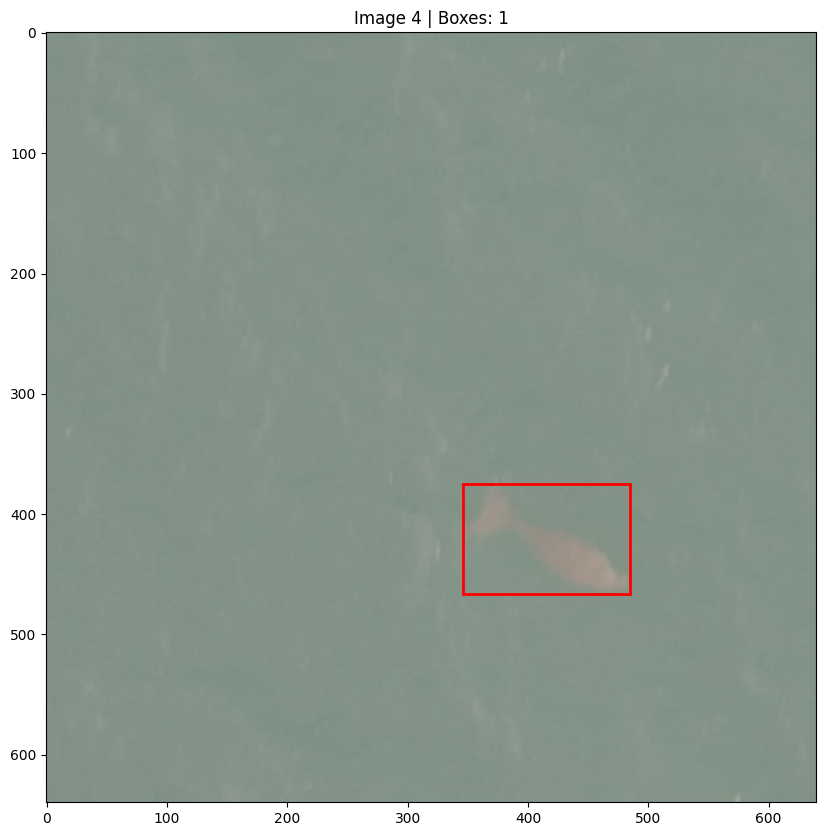

In [88]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle

def plot_sample(dataset, idx=0):
    pixel_values, labels = dataset[idx]
    image = pixel_values.permute(1, 2, 0).numpy()  # (H, W, C)
    image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0,1]

    # Denormalize (if needed)
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()

    # Draw boxes (RT-DETR format: [cx, cy, w, h])
    for box in labels["boxes"]:
        cx, cy, w, h = box.tolist()
        img_w, img_h = labels["orig_size"]
        x_min = (cx - w / 2) * img_w
        y_min = (cy - h / 2) * img_h
        x_max = (cx + w / 2) * img_w
        y_max = (cy + h / 2) * img_h
        rect = Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            fill=False, color="red", linewidth=2
        )
        ax.add_patch(rect)
    plt.title(f"Image {idx} | Boxes: {len(labels['boxes'])}")
    plt.show()

# Example usage:
plot_sample(dataset, idx=4)

In [87]:
def load_data_from_json(
    json_path: Union[str, Path],
    seed: str,
    schema: str,       # "aclr" or "random"
    partition: str,    # e.g., "p5", "p10"
) -> Dict[str, Tuple[List[Path], List[Path]]]:
    """
    Load train/val/test filepaths from your JSON structure.

    Args:
        json_path: Path to the JSON file.
        seed: Seed key (e.g., "0").
        schema: Partition schema ("aclr" or "random").
        partition: Partition key (e.g., "p5").

    Returns:
        Dict with keys "train", "val", "test", each mapping to (image_paths, label_paths).
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    # Extract paths for each split
    def get_split_paths(split: str) -> Tuple[List[Path], List[Path]]:
        if split == "train":
            split_data = data[seed]["train"][partition][schema]
        else:
            split_data = data[seed][split]
        return (
            [Path(p) for p in split_data["images"]],
            [Path(p) for p in split_data["labels"]],
        )

    return {
        "train": get_split_paths("train"),
        "val": get_split_paths("val"),
        "test": get_split_paths("test"),
    }

In [59]:
filepaths['train']

([PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_2200_0_p.jpg'),
  PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_0_3520_n.jpg'),
  PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_2640_0_p.jpg'),
  PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_2640_440_p.jpg'),
  PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M48_F1_2025_GSP-697e1055e6795_773__tile_2200_440_p.jpg'),
  PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200/images/FPLAN_P4P_UM_M33_F1_2025_GSP-697b1d86c5e8c_41__tile_1320_1760_p.jpg'),
  PosixPath('/share/home/e2406743/dataset/exported_img/new_dataset_flplan200

In [47]:
from transformers import AutoImageProcessor

# --- 1. Load JSON Data ---
seed = "0"
schema = "aclr"  # or "random"
partition = "p5"
json_filepaths = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/splits_json/splits_seeds012_mapped.json"
filepaths = load_data_from_json(json_filepaths, 
                                seed, 
                                schema, 
                                partition
                                )

# --- 2. Initialize Processor ---
checkpoint = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/checkpoints/NNN_NC_SEED63_augm_0510_1843/hf_export"

autoimage_processor = AutoImageProcessor.from_pretrained(
    checkpoint,
    do_resize=True,
    size={"width": 640, "height": 640},  # Match RT-DETR's expected input size
    use_fast=True,
)

# --- 3. Define Augmentations ---
train_augmentor = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.HueSaturationValue(p=0.1),
        A.Perspective(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"],
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

val_augmentor = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="coco",
        label_fields=["class_labels"],
        clip=True,
        min_area=1,
        min_width=1,
        min_height=1,
    ),
)

# --- 4. Create DataModule ---
data_module = DugongDataModule(
    train_image_filepaths=filepaths["train"][0],
    train_label_filepaths=filepaths["train"][1],
    val_image_filepaths=filepaths["val"][0],
    val_label_filepaths=filepaths["val"][1],
    test_image_filepaths=filepaths["test"][0],
    test_label_filepaths=filepaths["test"][1],
    processor=autoimage_processor,
    batch_size=8,
    num_workers=4,
    train_augmentor=train_augmentor,
    val_augmentor=val_augmentor,
)

# # --- 5. Use with PyTorch Lightning Trainer ---
# trainer = pl.Trainer(
#     max_epochs=50,
#     accelerator="auto",
#     devices="auto",
#     precision="16-mixed",
# )
# trainer.fit(model, datamodule=data_module)

In [49]:
from matplotlib import pyplot as plt

def plot_sample(dataset, idx=0):
    pixel_values, labels = dataset[idx]
    image = pixel_values.permute(1, 2, 0).numpy()  # (H, W, C)
    image = (image - image.min()) / (image.max() - image.min())  # Normalize to [0,1]

    # Denormalize if needed (AutoImageProcessor uses ImageNet stats)
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()

    # Draw boxes
    for box in labels["boxes"]:
        cx, cy, w, h = box.tolist()
        x_min = (cx - w / 2) * labels["orig_size"][1]
        y_min = (cy - h / 2) * labels["orig_size"][0]
        x_max = (cx + w / 2) * labels["orig_size"][1]
        y_max = (cy + h / 2) * labels["orig_size"][0]
        rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, fill=False, color="red", linewidth=2)
        ax.add_patch(rect)
    plt.show()



In [51]:
data_module.setup("fit")

In [55]:
data_module.train_dataset.__getitem__(0)

StrictDataclassFieldValidationError: Validation error for field 'annotations':
    TypeError: Field 'annotations' with value {'image_id': 0, 'annotations': {'boxes': tensor([], size=(0, 4)), 'class_labels': tensor([], dtype=torch.int64), 'image_id': tensor(0), 'orig_size': tensor([640., 640.]), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64)}} doesn't match any type in (dict[str, int | str | list[dict]], list[dict[str, int | str | list[dict]]], <class 'NoneType'>). Errors: Invalid key or value in dict 'annotations'; Field 'annotations' expected a list, got dict; Field 'annotations' expected NoneType, got dict (value: {'image_id': 0, 'annotations': {'boxes': tensor([], size=(0, 4)), 'class_labels': tensor([], dtype=torch.int64), 'image_id': tensor(0), 'orig_size': tensor([640., 640.]), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64)}})

In [52]:
# Example usage:
plot_sample(data_module.train_dataset, idx=0)

StrictDataclassFieldValidationError: Validation error for field 'annotations':
    TypeError: Field 'annotations' with value {'image_id': 0, 'annotations': {'boxes': tensor([], size=(0, 4)), 'class_labels': tensor([], dtype=torch.int64), 'image_id': tensor(0), 'orig_size': tensor([640., 640.]), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64)}} doesn't match any type in (dict[str, int | str | list[dict]], list[dict[str, int | str | list[dict]]], <class 'NoneType'>). Errors: Invalid key or value in dict 'annotations'; Field 'annotations' expected a list, got dict; Field 'annotations' expected NoneType, got dict (value: {'image_id': 0, 'annotations': {'boxes': tensor([], size=(0, 4)), 'class_labels': tensor([], dtype=torch.int64), 'image_id': tensor(0), 'orig_size': tensor([640., 640.]), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64)}})